In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [44]:
df = pd.read_csv("life_expectancy_test_master.csv")
df.head()

,Year,AdultMortality,InfantMortality,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,...,Schooling,Status_Encoded,health_efficiency_ratio,health_gdp_ratio,log_GDP,development_index,disease_index,mortality_health_interaction,education_income_interaction,LifeExpectancy
0,2006.0,-0.341889,-0.185965,-0.914219,-0.306254,-0.007474,-0.155491,0.495290,-0.196816,0.010500,...,-0.197655,0.0,-0.286226,-0.244401,0.002410,0.412128,0.057807,-0.568209,-0.225981,73.7
1,2006.0,-0.421863,-0.257514,1.869260,0.427789,0.387715,-0.200024,0.976232,-0.262215,0.568389,...,0.570757,1.0,-0.185883,-0.273823,1.090628,0.530929,0.051708,-0.193291,0.677911,75.9
2,2007.0,-0.325894,-0.257514,0.113566,-0.021515,-3.256806,-0.200110,0.931143,-0.262215,0.396731,...,0.478547,0.0,-0.210483,-0.263844,0.713512,0.503592,0.057248,-0.126419,0.548421,74.2
3,2014.0,-1.269593,-0.257514,-0.760436,-0.180958,0.651174,-0.196140,1.216702,-0.262215,0.654218,...,0.755175,0.0,1.662684,-0.281739,1.550696,0.591697,0.002770,-1.071454,0.928259,76.8
4,2000.0,2.097331,0.431141,-0.775814,-0.368732,0.387715,1.612415,-1.213053,0.529116,-3.208088,...,-1.119749,0.0,-0.350666,1.712402,-2.140176,0.292909,0.330209,1.231550,-1.093527,51.9


In [46]:
print(df.shape)
print(df.info())
print(df.describe())

(588, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          588 non-null    float64
 1   AdultMortality                588 non-null    float64
 2   InfantMortality               588 non-null    float64
 3   Alcohol                       588 non-null    float64
 4   percentage expenditure        588 non-null    float64
 5   Hepatitis B                   588 non-null    float64
 6   Measles                       588 non-null    float64
 7   BMI                           588 non-null    float64
 8   under-five deaths             588 non-null    float64
 9   Polio                         588 non-null    float64
 10  HealthExpenditure             588 non-null    float64
 11  Diphtheria                    588 non-null    float64
 12  HIV_AIDS                      588 non-null    float64


In [47]:
print(df.isnull().sum())

Year                            0
AdultMortality                  0
InfantMortality                 0
Alcohol                         0
percentage expenditure          0
Hepatitis B                     0
Measles                         0
BMI                             0
under-five deaths               0
Polio                           0
HealthExpenditure               0
Diphtheria                      0
HIV_AIDS                        0
GDP                             0
Population                      0
thinness  1-19 years            0
thinness 5-9 years              0
IncomeLevel                     0
Schooling                       0
Status_Encoded                  0
health_efficiency_ratio         0
health_gdp_ratio                0
log_GDP                         0
development_index               0
disease_index                   0
mortality_health_interaction    0
education_income_interaction    0
LifeExpectancy                  0
dtype: int64


In [17]:
print(df.columns)

Index(['Year', 'AdultMortality', 'InfantMortality', 'Alcohol',
       'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI',
       'under-five deaths', 'Polio', 'HealthExpenditure', 'Diphtheria',
       'HIV_AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'IncomeLevel', 'Schooling', 'Status_Encoded',
       'health_efficiency_ratio', 'health_gdp_ratio', 'log_GDP',
       'development_index', 'disease_index', 'mortality_health_interaction',
       'education_income_interaction', 'LifeExpectancy'],
      dtype='object')


In [48]:
imputer = SimpleImputer(strategy='mean')
df[df.columns] = imputer.fit_transform(df)

In [49]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | 
          (df > (Q3 + 1.5 * IQR))).any(axis=1)]

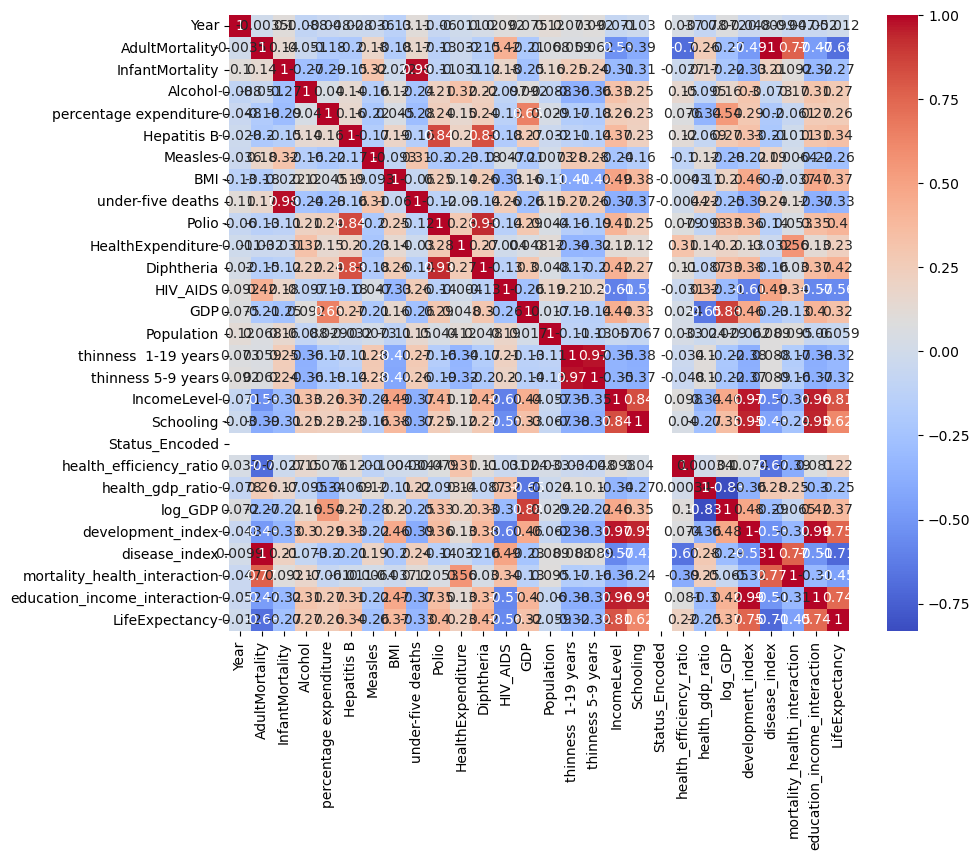

In [51]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [80]:
X = df.drop("LifeExpectancy", axis=1)   # Example target
y = df["LifeExpectancy"]

In [53]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(len(X.columns))]
print(vif_data)

C:\Users\sadiy\anaconda3.1\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\sadiy\anaconda3.1\Lib\site-packages\statsmodels\regression\linear_model.py:1781: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


                         Feature         VIF
0                           Year    1.221833
1                 AdultMortality         inf
2                InfantMortality         inf
3                        Alcohol    2.025307
4         percentage expenditure    2.217626
5                    Hepatitis B    4.785388
6                        Measles    1.426720
7                            BMI    1.808670
8              under-five deaths   66.171624
9                          Polio   10.233274
10             HealthExpenditure   11.224983
11                    Diphtheria    9.377743
12                      HIV_AIDS         inf
13                           GDP         inf
14                    Population    1.282060
15          thinness  1-19 years   21.823386
16            thinness 5-9 years   21.566592
17                   IncomeLevel         inf
18                     Schooling         inf
19                Status_Encoded         NaN
20       health_efficiency_ratio    4.550495
21        

In [54]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [57]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [58]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 70.1686850351594
Slope: 0.21024902924583946


In [59]:
y_pred = model.predict(X_test)

In [60]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.5325025530204495
RMSE: 2.0585764084640013
R2 Score: 0.8578825125774813


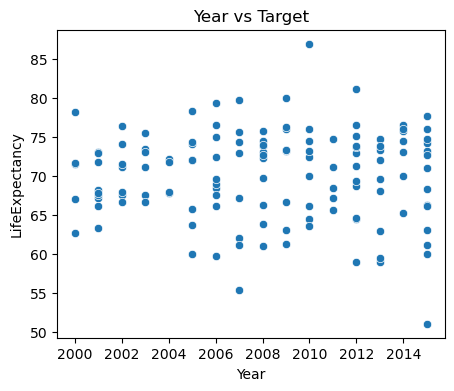

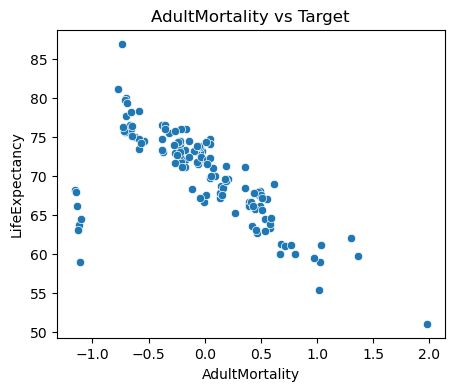

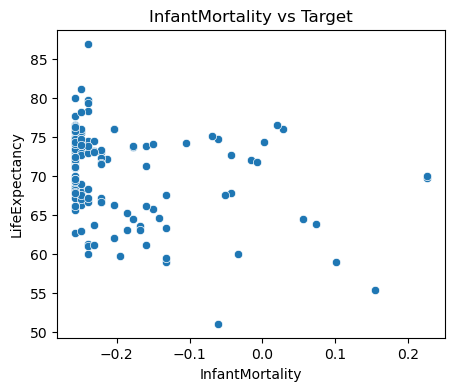

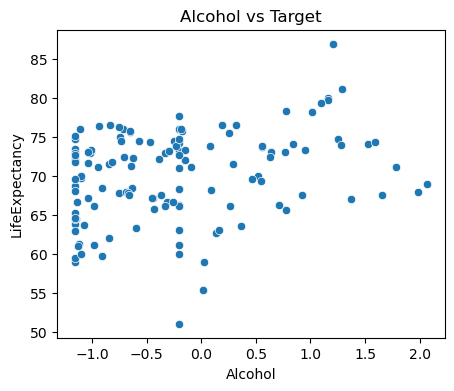

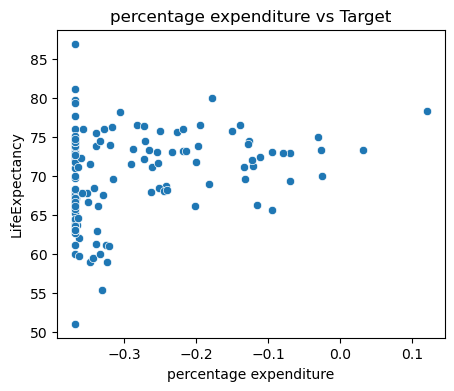

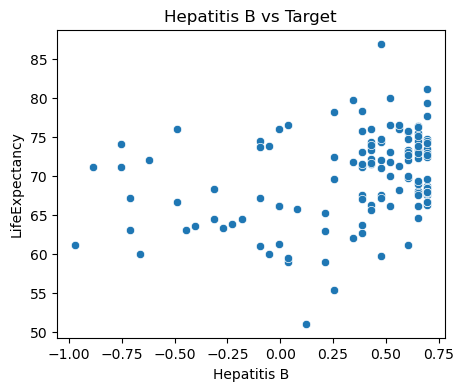

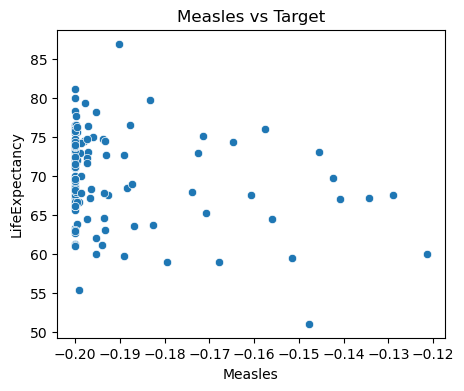

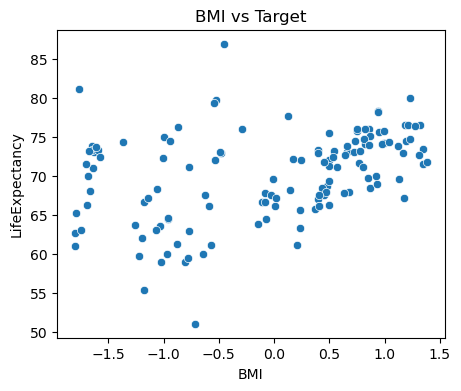

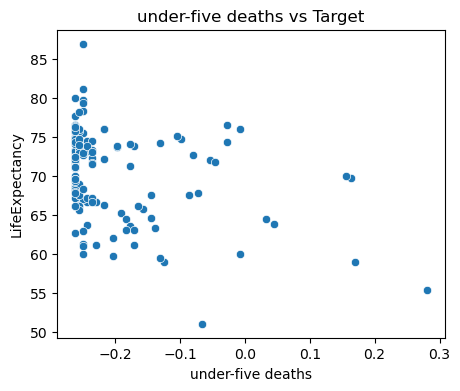

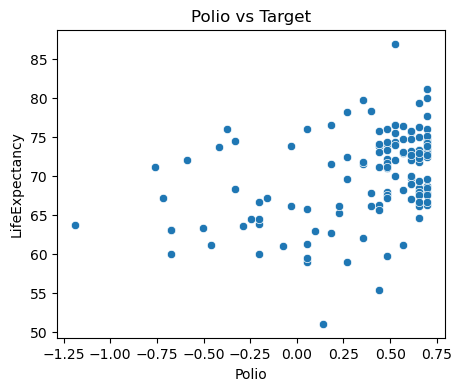

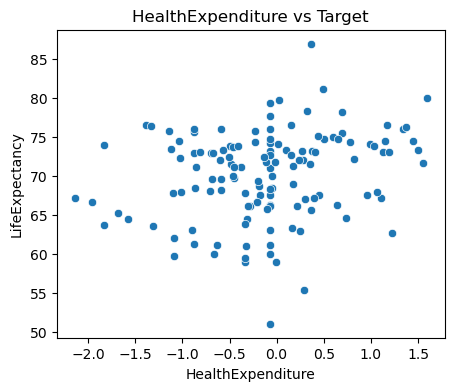

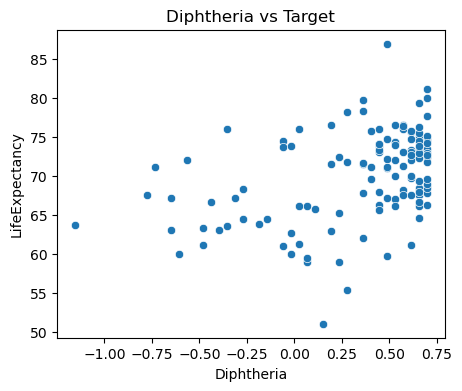

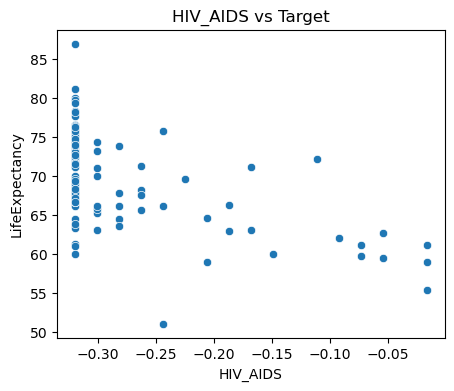

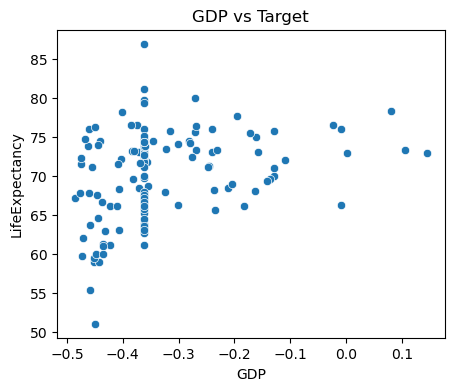

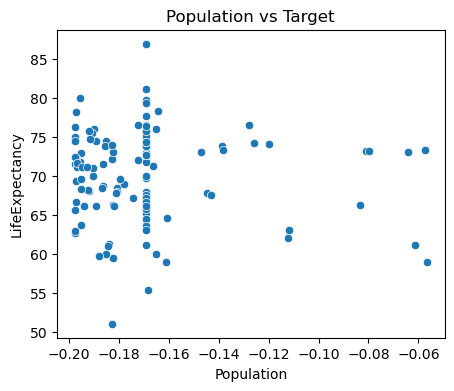

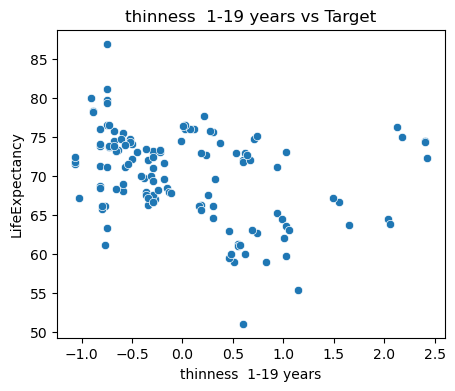

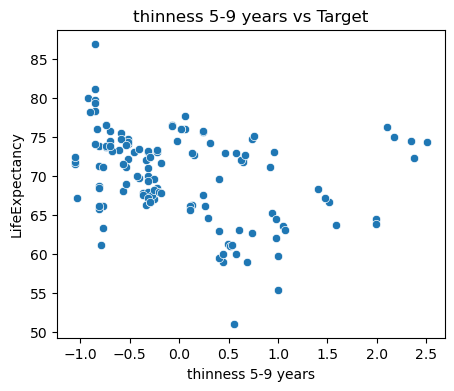

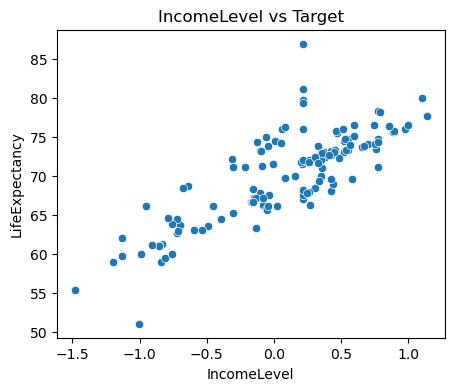

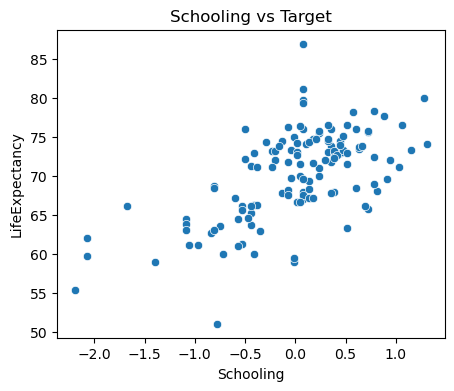

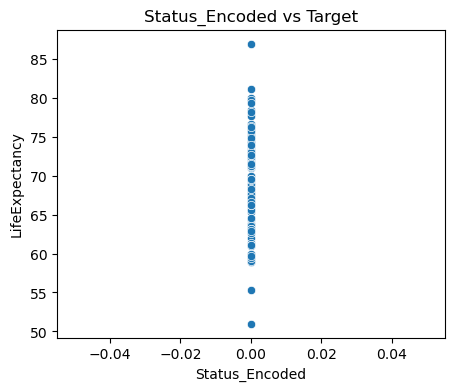

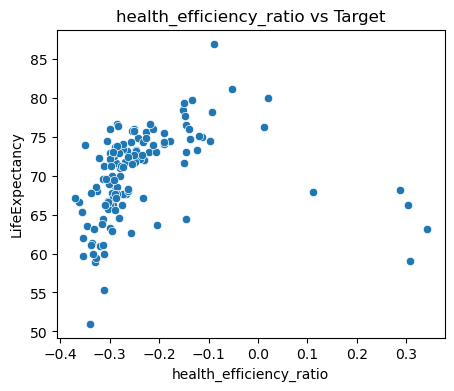

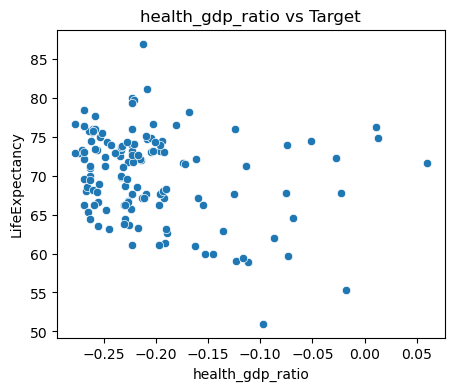

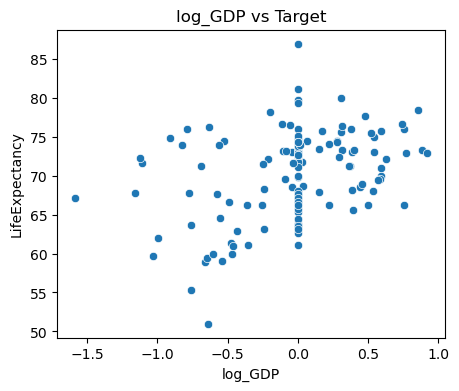

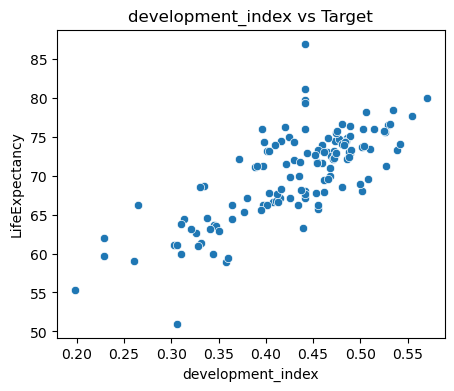

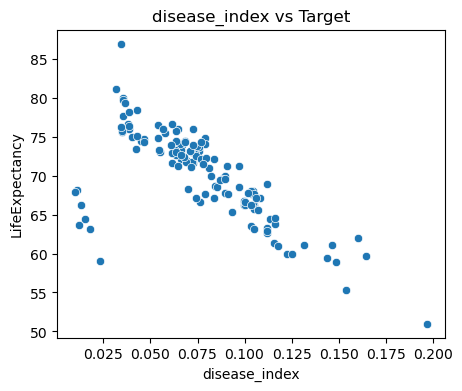

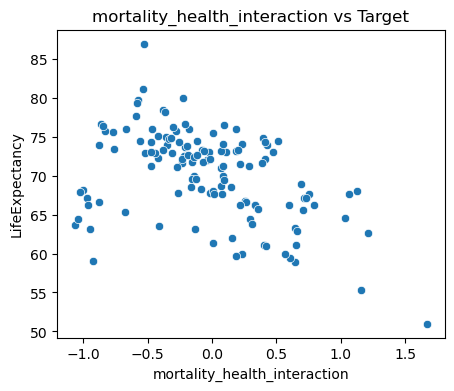

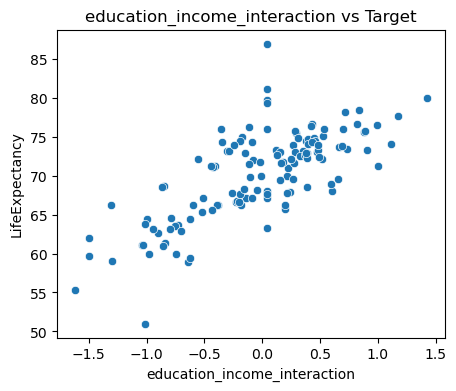

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in X.columns:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=X[column], y=y)
    plt.title(f"{column} vs Target")
    plt.show()

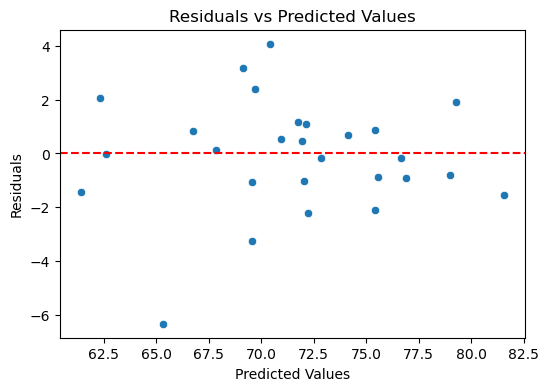

In [85]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

In [62]:
residuals = y_test - y_pred

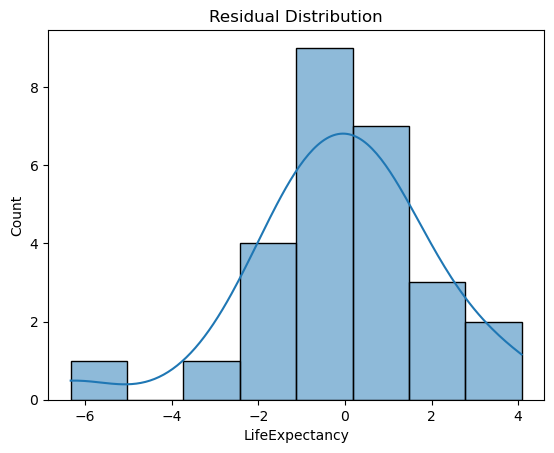

In [84]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

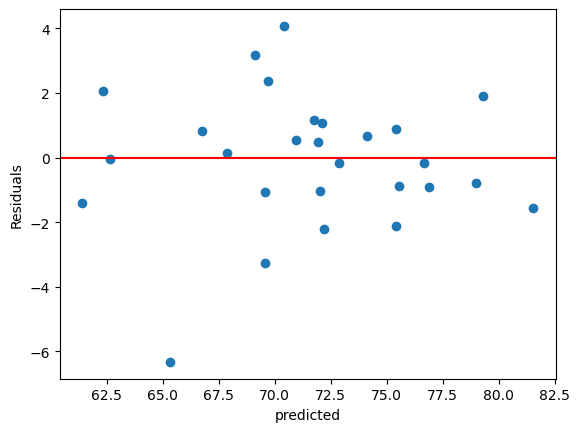

In [76]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("predicted")
plt.ylabel("Residuals")
plt.show()

In [77]:
X_sm = sm.add_constant(X_scaled)
model_sm = sm.OLS(y, X_sm).fit()

print(sm.stats.stattools.durbin_watson(model_sm.resid))

2.1573868505414366
